# Ingeniería de características


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib
import json

## Cargar datos

In [25]:
df = pd.read_csv("../data/processed/olist_eda.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_purchase_timestamp       118434 non-null  str    
 3   customer_unique_id             118434 non-null  str    
 4   order_item_id                  117604 non-null  float64
 5   product_category_name_english  115881 non-null  str    
 6   payment_value                  118431 non-null  float64
dtypes: float64(2), str(5)
memory usage: 6.3 MB


## Análisis de outliers

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_item_id,117604.0,1.195920,0.697721,1.0,1.00,1.0,1.000,21.00
payment_value,118431.0,172.849395,268.259831,0.0,60.86,108.2,189.245,13664.08


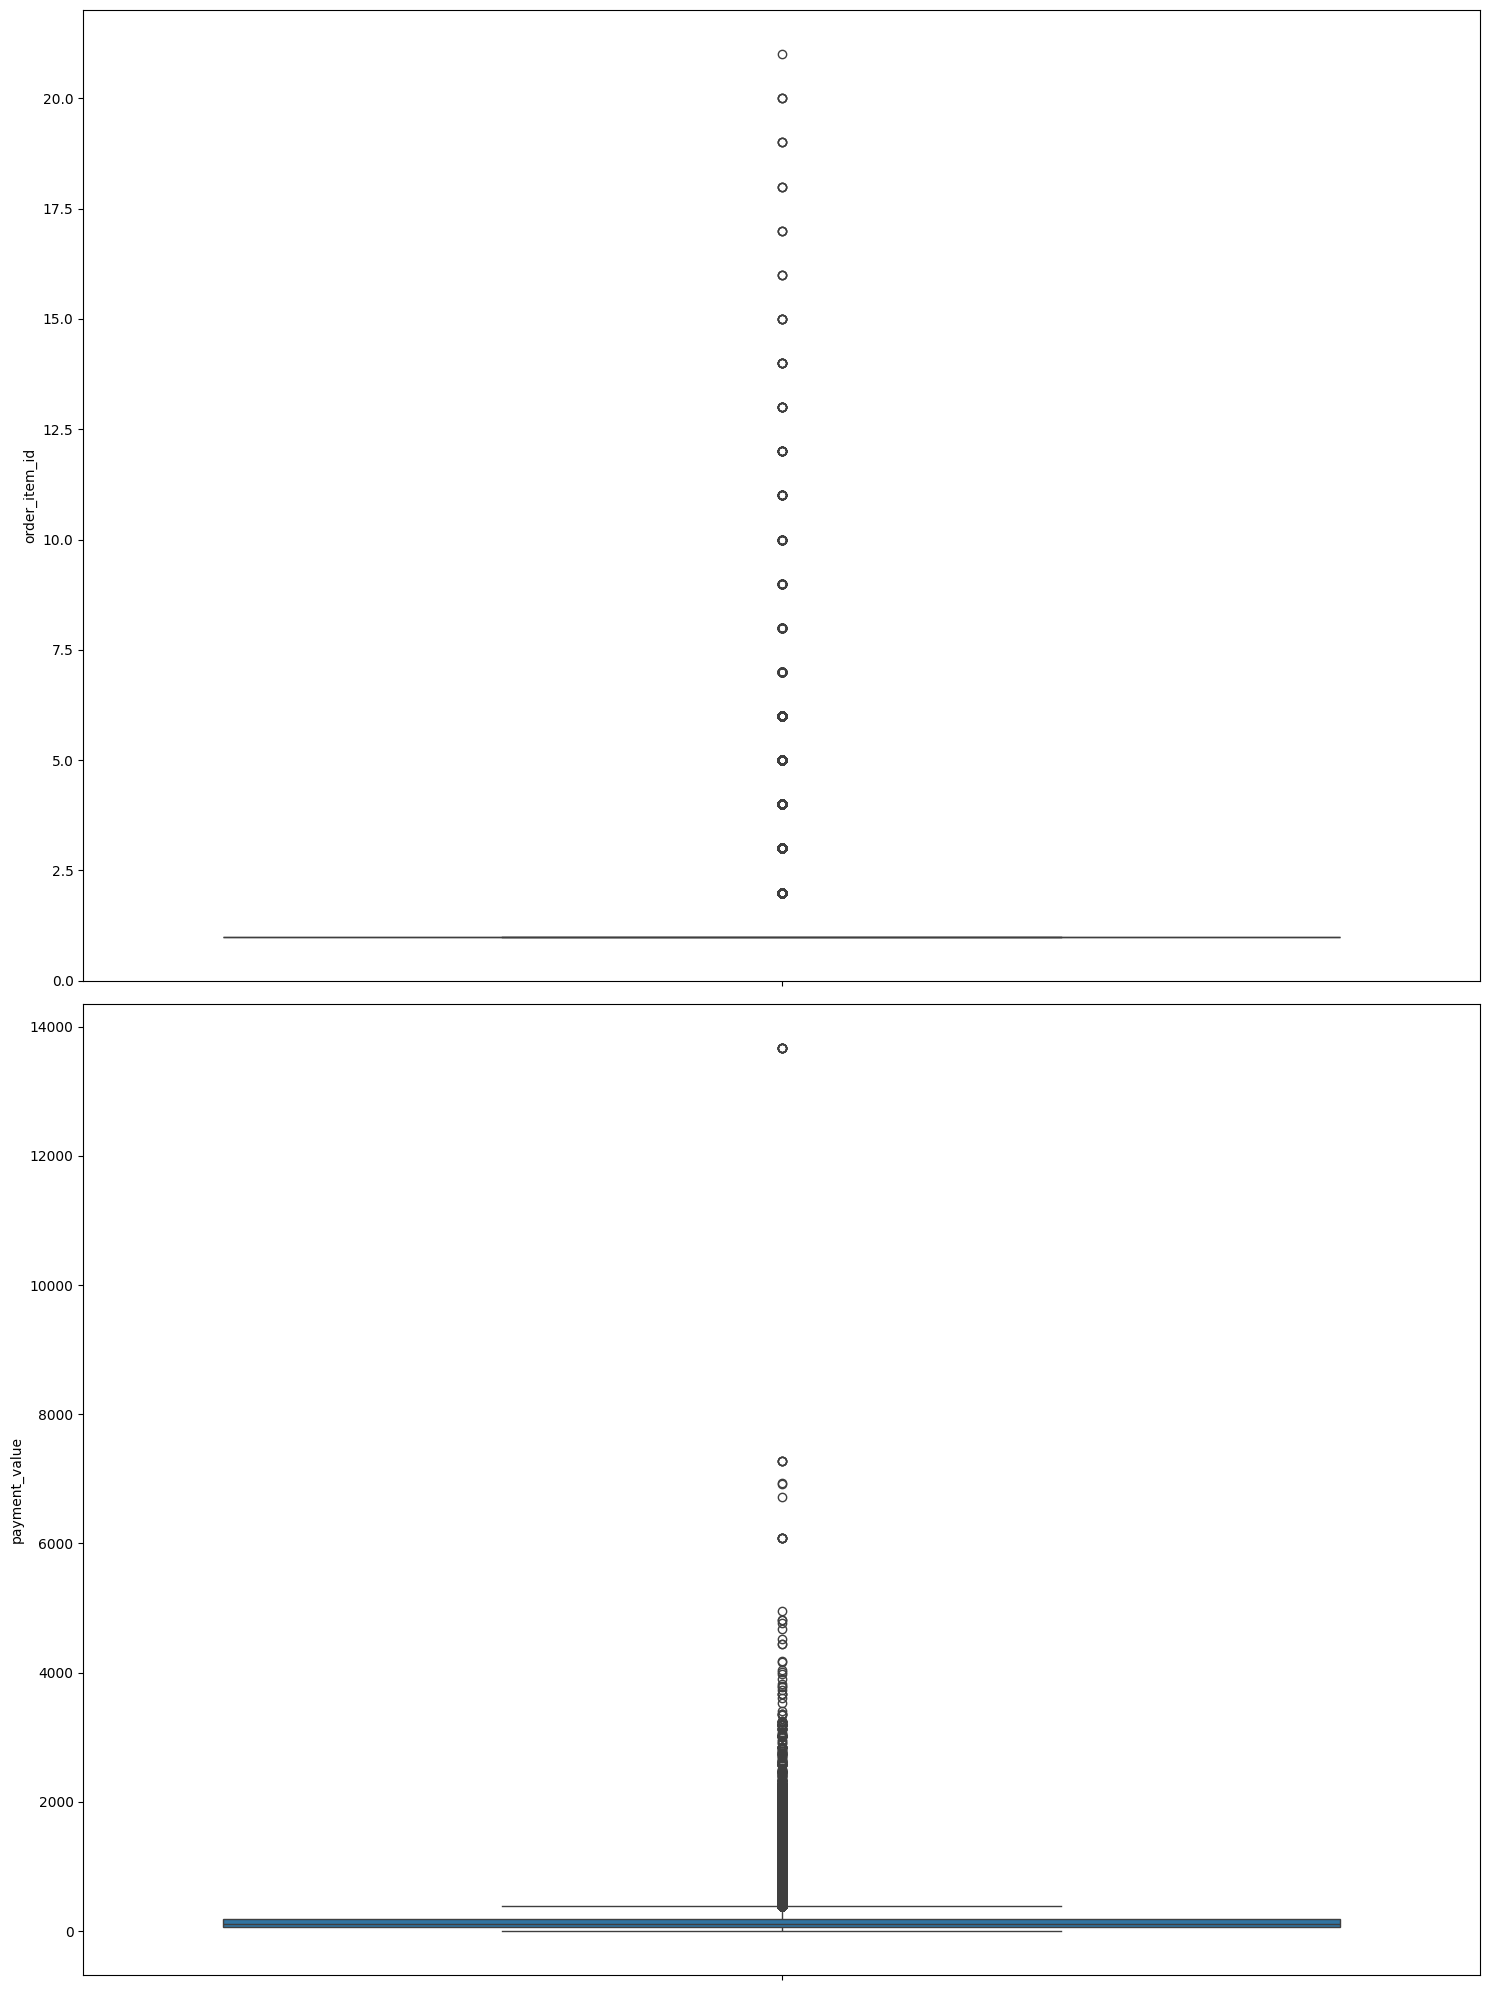

In [27]:
fig, axis = plt.subplots(2, 1, figsize=(15, 20))

sns.boxplot(ax=axis[0], data=df, y="order_item_id")
sns.boxplot(ax=axis[1], data=df, y="payment_value")

plt.tight_layout()

##### Observaciones:
> -  En lo observado con el análisis univariante, decido manetener los valores atipicos porqué existe una relacion en el aumento del precio con la cantidad de productos agrupados en una misma orden.

#### Análisis de valores faltantes

In [28]:
df.shape[1]

7

In [29]:
df.isnull().sum().sort_values(ascending=False) / len(df)

product_category_name_english    0.021556
order_item_id                    0.007008
payment_value                    0.000025
order_purchase_timestamp         0.000000
customer_id                      0.000000
order_id                         0.000000
customer_unique_id               0.000000
dtype: float64

In [30]:
df[df["product_category_name_english"].isnull()]

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,2017-04-11 12:22:08,36edbb3fb164b1f16485364b6fb04c73,1.0,NaN,65.95
129,bfe42c22ecbf90bc9f35cf591270b6a7,803ac05904124294f8767894d6da532b,2018-01-27 22:04:34,34c58672601f2c6d29db7efd1f6bf958,1.0,NaN,42.40
221,58ac1947c1a9067b9f416cba6d844a3f,ee8e1d37f563ecc11cc4dcb4dfd794c2,2017-09-13 09:18:50,5cbf29b2dcf212a6a5d864b887238c72,1.0,NaN,124.16
274,e22b71f6e4a481445ec4527cb4c405f7,1faf89c8f142db3fca6cf314c51a37b6,2017-04-22 13:48:18,1268b060098ed3f22c2e7c34cc72a1a8,1.0,NaN,34.24
316,a094215e786240fcfefb83d18036a1cd,86acfb656743da0c113d176832c9d535,2018-02-08 18:56:45,f5cb81f98962f7504bef1e75579b6dff,1.0,NaN,132.05
...,...,...,...,...,...,...,...
118205,aaab15da689073f8f9aa978a390a69d1,df20748206e4b865b2f14a5eabbfcf34,2018-01-16 14:27:59,a33e0969408919ba06779f497ead93ec,NaN,NaN,210.09
118237,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,2018-08-31 16:13:44,e90598185d2427a35e32ef241a5c04aa,NaN,NaN,63.89
118330,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,2018-09-06 18:45:47,d05c44a138277ad325d915c6b7ccbcdf,NaN,NaN,107.13
118331,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,2017-08-23 16:28:04,e72a90a2b29fe1a8795b284aaaa3246f,NaN,NaN,195.91


In [31]:
df.dropna(inplace=True)
df.isnull().sum()

order_id                         0
customer_id                      0
order_purchase_timestamp         0
customer_unique_id               0
order_item_id                    0
product_category_name_english    0
payment_value                    0
dtype: int64

In [32]:
# Convertimos la columna a formato fecha
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [33]:
# Extraemos información valiosa
df['month'] = df['order_purchase_timestamp'].dt.month
df['day_of_week'] = df['order_purchase_timestamp'].dt.weekday
df['hour'] = df['order_purchase_timestamp'].dt.hour

In [34]:
df["payment_value"]

0          18.12
1           2.00
2          18.59
3         141.46
4         179.12
           ...  
118429    195.00
118430    271.01
118431    441.16
118432    441.16
118433     86.86
Name: payment_value, Length: 115878, dtype: float64

### Renombrar variables

In [35]:
df = df.rename(columns={"product_category_name_english":"product_category_name"})

In [36]:
df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'customer_unique_id', 'order_item_id', 'product_category_name',
       'payment_value', 'month', 'day_of_week', 'hour'],
      dtype='str')

## Escalado

### StandardScaler

In [37]:
df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'customer_unique_id', 'order_item_id', 'product_category_name',
       'payment_value', 'month', 'day_of_week', 'hour'],
      dtype='str')

In [38]:
cols_to_scale = ["payment_value", "month", "hour", "day_of_week"]
scaler = StandardScaler()

In [ ]:
df_scaled = df.copy()

In [40]:
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

In [41]:
df_scaled = df_scaled[["payment_value", "month", "hour", "day_of_week", "product_category_name"]]

In [42]:
df.head(5)

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name,payment_value,month,day_of_week,hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.12,10,0,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,2.00,10,0,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,1.0,housewares,18.59,10,0,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,1.0,perfumery,141.46,7,1,20
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,1.0,auto,179.12,8,2,8


In [43]:
df_scaled.head(5)

,payment_value,month,hour,day_of_week,product_category_name
0,-0.577736,1.230778,-0.894707,-1.399822,housewares
1,-0.637860,1.230778,-0.894707,-1.399822,housewares
2,-0.575983,1.230778,-0.894707,-1.399822,housewares
3,-0.117700,0.300016,0.983385,-0.889928,perfumery
4,0.022764,0.610270,-1.270326,-0.380034,auto


## Guardar Datos

dataframe

In [44]:
df.to_csv("../data/processed/olist_engineering.csv", index=False)

df_scaled


In [45]:
df_scaled.to_csv("../data/processed/olist_scaled.csv", index=False)